In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from cv_functions import *

In [3]:
def get_phase_from_image(img, mask_radius = 15, filter_radius = 15):
    fft = np.fft.fftshift(np.fft.fft2(img))
    spectrum = np.log(1 + np.abs(fft))
    f_x, f_y = find_plus_one_order_position(spectrum, mask_radius = mask_radius)
    filtered_spectrum = filter_spectrum(fft, f_x, f_y, radius=filter_radius)
    centered_spectrum = center_spectrum(filtered_spectrum, f_x, f_y)
    complex_field = np.fft.ifft2(np.fft.ifftshift(centered_spectrum))
    phase_wrapped = np.angle(complex_field)
    phase_unwrapped = unwrap_phase(phase_wrapped)
    return phase_unwrapped

In [51]:
img = cv2.imread(r"erythrocytes_output/Blood Cells 3_erythrocyte_1.png", cv2.IMREAD_GRAYSCALE)

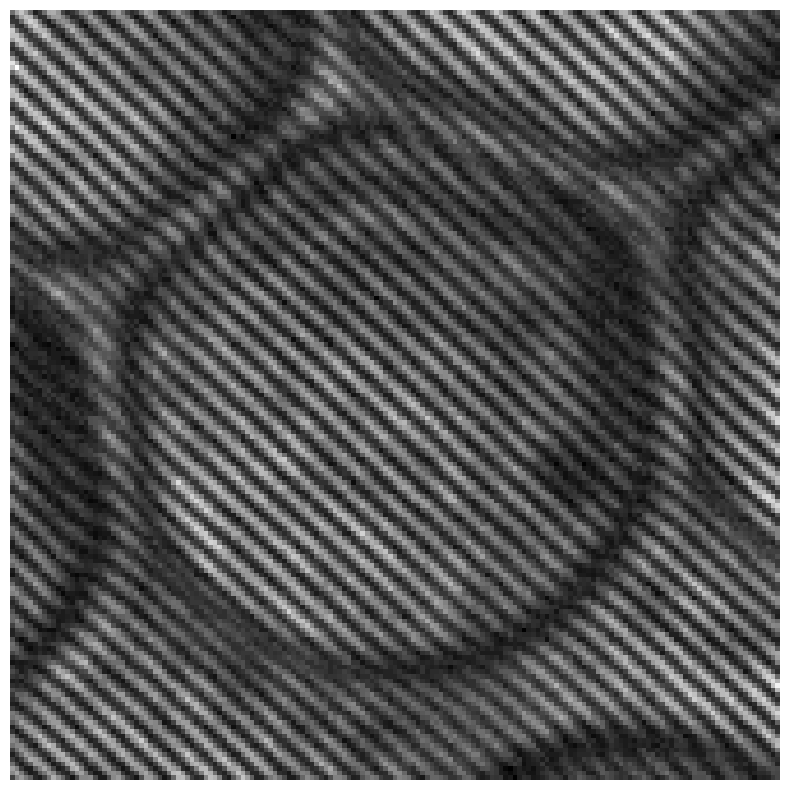

In [53]:
plt.figure(figsize=(10, 10))
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [19]:
def carrier_frequency(img, mask_radius=15):
    """Return (+1 order coords, carrier distance f_c, log-spectrum)."""
    h, w = img.shape
    cy, cx = h // 2, w // 2
    fft = np.fft.fftshift(np.fft.fft2(img))
    spectrum = np.log(1 + np.abs(fft))
    f_x, f_y = find_plus_one_order_position(spectrum, mask_radius=mask_radius)
    f_c = float(np.hypot(f_x - cx, f_y - cy))
    return f_x, f_y, f_c, spectrum

In [21]:
def background_noise(phase, frac=0.12):
    """Std of the phase over a corner patch — proxy for reconstruction noise."""
    h, w = phase.shape
    bh, bw = max(8, int(h * frac)), max(8, int(w * frac))
    return float(np.std(phase[:bh, :bw]))

In [23]:

from fractions import Fraction

In [25]:
def _fmt_factor(k):
    """Format a radius factor as a simple fraction: 0.5 -> '1/2', 1.0 -> '1'."""
    fr = Fraction(k).limit_denominator(16)
    if fr.denominator == 1:
        return str(fr.numerator)
    return f"{fr.numerator}/{fr.denominator}"
 

In [35]:
def compare_filter_radii(
    img,
    factors=(0.25, 0.5, 0.75, 1.0),
    mask_radius=15,
    cmap="gray",
    show_spectrum=True,
    save_path="phase_radius_comparison.png",
):
    if img is None:
        raise ValueError("img is None")
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
 
    f_x, f_y, f_c, spectrum = carrier_frequency(img, mask_radius)
    radii = [max(2, int(round(f_c * k))) for k in factors]
 
    n = len(radii)
    ncols = 2 if show_spectrum else 1
    fig, axes = plt.subplots(
        n, ncols, figsize=(3.2 * ncols, 2.7 * n), squeeze=False
    )
 
    for i, (k, R) in enumerate(zip(factors, radii)):
        phase_col = 0
        if show_spectrum:
            ax = axes[i, 0]
            ax.imshow(spectrum, cmap="gray")
            ax.add_patch(plt.Circle((f_x, f_y), R, color="red", fill=False, lw=1.5))
            ax.set_title(f"R = {_fmt_factor(k)}·f_c = {R} px", fontsize=11)
            ax.axis("off")
            phase_col = 1
 
        phase = get_phase_from_image(img, mask_radius=mask_radius, filter_radius=R)
        axp = axes[i, phase_col]
        axp.imshow(phase, cmap=cmap)
        if not show_spectrum:
            axp.set_title(f"R = {_fmt_factor(k)}·f_c = {R} px", fontsize=11)
        axp.axis("off")

    plt.tight_layout(rect=(0, 0, 1, 0.97))
    plt.savefig(save_path, dpi=130, bbox_inches="tight")
    plt.show()
 
    print(f"f_c = {f_c:.0f} px | radii = {radii} | saved -> {save_path}")
    return radii, f_c
 

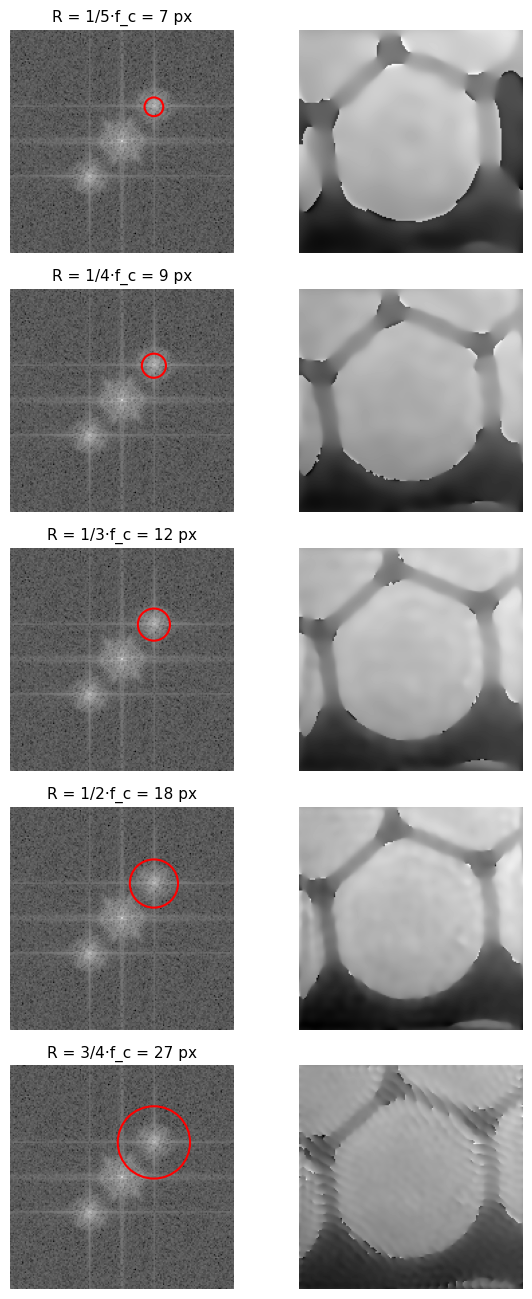

f_c = 35 px | radii = [7, 9, 12, 18, 27] | saved -> phase_radius_comparison.png


([7, 9, 12, 18, 27], 35.38361202590826)

In [55]:
from fractions import Fraction
compare_filter_radii(img, factors=(Fraction(1,5), Fraction(1,4), Fraction(1,3), Fraction(1,2), Fraction(3,4)))

In [65]:
img = cv2.imread(r"Images\Image 1b\Img1.bmp", cv2.IMREAD_GRAYSCALE)

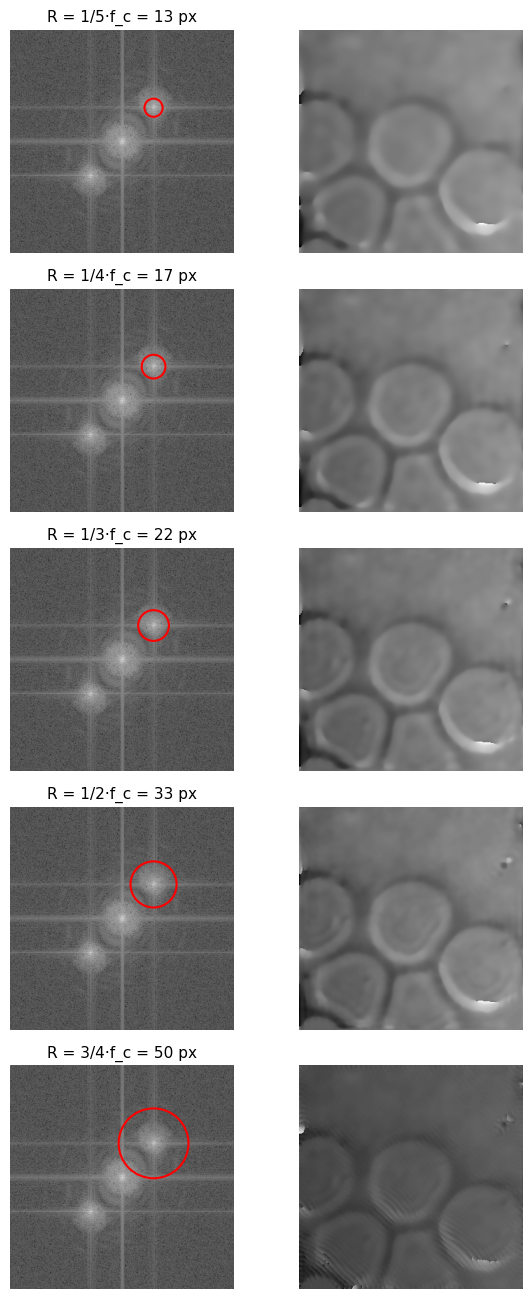

f_c = 67 px | radii = [13, 17, 22, 33, 50] | saved -> phase_radius_comparison_2.png


([13, 17, 22, 33, 50], 66.52818951391959)

In [67]:
compare_filter_radii(img, factors=(Fraction(1,5), Fraction(1,4), Fraction(1,3), Fraction(1,2), Fraction(3,4)), save_path="phase_radius_comparison_2.png")